In [1]:
import pandas as pd
import numpy as np
from PIL import Image

In [2]:
import os
import cv2
import numpy as np

images = []
labels = []

data_dir = "data"

class_names = ["with_mask", "without_mask"]

for label, class_name in enumerate(class_names):
    folder_path = os.path.join(data_dir, class_name)

    for file_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file_name)

        img = cv2.imread(img_path)

        if img is not None:
            # Convert to grayscale
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Resize to 100 x 100
            img = cv2.resize(img, (100, 100))

            # Flatten: (100,100) -> (10000,)
            img = img.flatten()

            # Normalize pixel values
            img = img / 255.0

            images.append(img)
            labels.append(label)

images = np.array(images)
labels = np.array(labels)

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print(le.classes_)

[0 1]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels_encoded,
    test_size=0.2,
    random_state=0
)

In [7]:
model = LogisticRegression(
    random_state=0,
    max_iter=500,
    tol=0.001,
    C=10
)

model.fit(X_train, y_train)

c:\Users\dipes\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [8]:
y_pred = model.predict(X_test)

In [9]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[485 264]
 [250 512]]


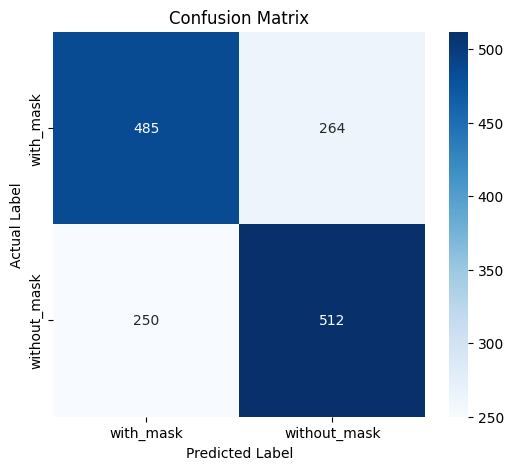

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['with_mask', 'without_mask'],
    yticklabels=['with_mask', 'without_mask']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')

plt.show()

In [11]:
X_train.shape
# (6042, 10000)

(6042, 10000)

In [12]:
import numpy as np

augmentation_factor = 2

np.random.seed(0)

angle_of_rotation = np.random.uniform(
    -180,
    180,
    augmentation_factor * len(X_train)
)

print(angle_of_rotation.shape)

(12084,)


In [13]:
from scipy.ndimage import rotate
import numpy as np

def augment_image(images, labels, angles, augmentation_factor):
    
    augmented_images = []
    augmented_labels = []

    # First add all original images
    for image, label in zip(images, labels):
        
        image = image.reshape(100, 100)
        
        augmented_images.append(image)
        augmented_labels.append(label)

    # Then create augmented images
    angle_index = 0

    for image, label in zip(images, labels):
        
        image = image.reshape(100, 100)

        for _ in range(augmentation_factor):
            
            rotated_image = rotate(
                image,
                angles[angle_index],
                reshape=False
            )

            augmented_images.append(rotated_image)
            augmented_labels.append(label)

            angle_index += 1

    return np.array(augmented_images), np.array(augmented_labels)

In [14]:
augmentation_factor = 2

np.random.seed(0)

angle_of_rotation = np.random.uniform(
    -180,
    180,
    augmentation_factor * len(X_train)
)

augmented_images, augmented_labels = augment_image(
    X_train,
    y_train,
    angle_of_rotation,
    augmentation_factor
)

In [15]:
answer = np.sum(augmented_labels[7000:8000])

print(answer)

510


In [16]:
augmented_images.shape
# (18126, 100, 100)

(18126, 100, 100)

In [17]:
X_aug_flat = augmented_images.reshape(len(augmented_images), -1)

print(X_aug_flat.shape)

(18126, 10000)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)

rf.fit(X_aug_flat, augmented_labels)

In [ ]:
top_100_features = np.argsort(rf.feature_importances_)[-100:]

In [ ]:
X_train_selected = X_aug_flat[:, top_100_features]

print(X_train_selected.shape)

In [ ]:
X_test_selected = X_test[:, top_100_features]

print(X_test_selected.shape)

In [ ]:
rf_selected = RandomForestClassifier(random_state=0)

rf_selected.fit(
    X_train_selected,
    augmented_labels
)

In [ ]:
y_pred_rf = rf_selected.predict(X_test_selected)

In [ ]:
misclassified = np.sum(y_pred_rf != y_test)

print("Misclassified data points:", misclassified)